# Credit Card Default Prediction - EDA and Model Training

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, f1_score, confusion_matrix, roc_auc_score, roc_curve
from catboost import CatBoostClassifier
import joblib
import kagglehub
import warnings

warnings.filterwarnings("ignore")

## 1. Loading the dataset

In [5]:
path = kagglehub.dataset_download("uciml/default-of-credit-card-clients-dataset")

df = pd.read_csv(f"{path}/UCI_Credit_Card.csv")

print(f"Shape: {df.shape}")
df.head()

Shape: (30000, 25)


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null  float64
 13  BILL_AMT2                   300

In [7]:
df.describe()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,15000.500000,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,8660.398374,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,1.000000,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,7500.750000,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,15000.500000,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,22500.250000,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,30000.000000,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


## 2. Target distribution

default.payment.next.month
0    23364
1     6636
Name: count, dtype: int64

Default rate: 22.1%


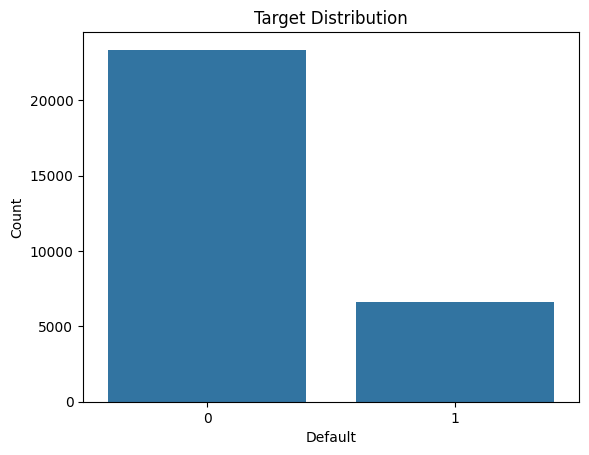

In [25]:
target = "default.payment.next.month"

counts = df[target].value_counts()
display(counts)
print(f"Default rate: {(counts[1] / len(df) * 100):.1f}%")

sns.barplot(counts)
plt.xlabel("Default")
plt.ylabel("Count")
plt.title("Target Distribution")
plt.show()

Датасет несбалансирован: 78% без дефолта, 22% с дефолтом. Accuracy здесь будет вводить в заблуждение, поэтому используем F1-score как основную метрику.

## 3. Feature distributions

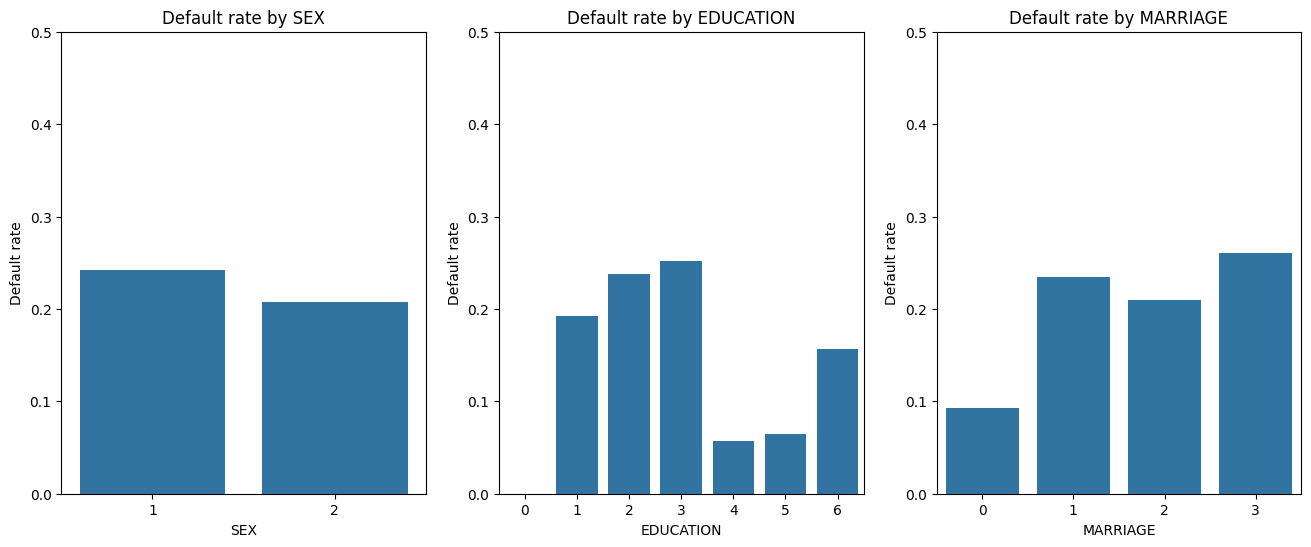

In [30]:
cat_features = ["SEX", "EDUCATION", "MARRIAGE"]
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

for ax, col in zip(axes, cat_features):
    sns.barplot(data=df, x=col, y=target, ax=ax, errorbar=None)
    ax.set_title(f"Default rate by {col}")
    ax.set_ylabel("Default rate")
    ax.set_ylim(0, 0.5)

plt.show()

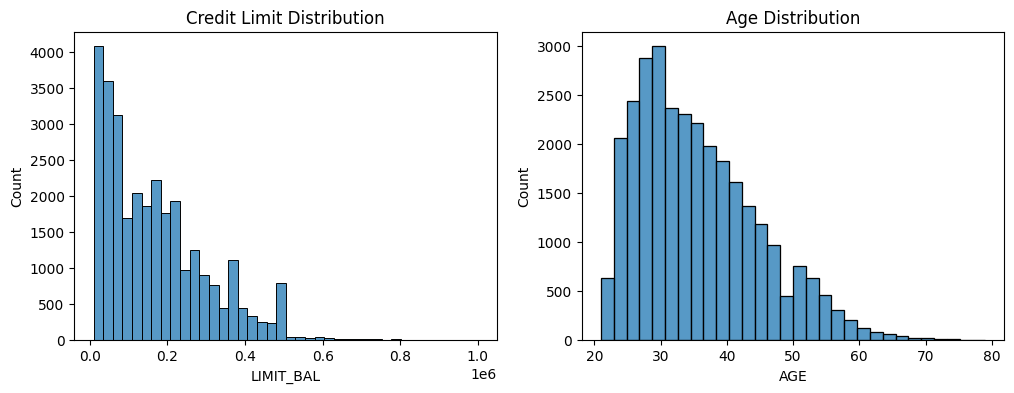

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df["LIMIT_BAL"], bins=40, ax=axes[0])
axes[0].set_title("Credit Limit Distribution")

sns.histplot(df["AGE"], bins=30, ax=axes[1])
axes[1].set_title("Age Distribution")

plt.show()

Default rate примерно одинаковый по SEX и MARRIAGE. EDUCATION показывает более низкий default rate для категорий 4-6 (другое/неизвестно). Кредитные лимиты скошены вправо, большинство клиентов в возрасте 25-45 лет.

## 4. Correlation matrix

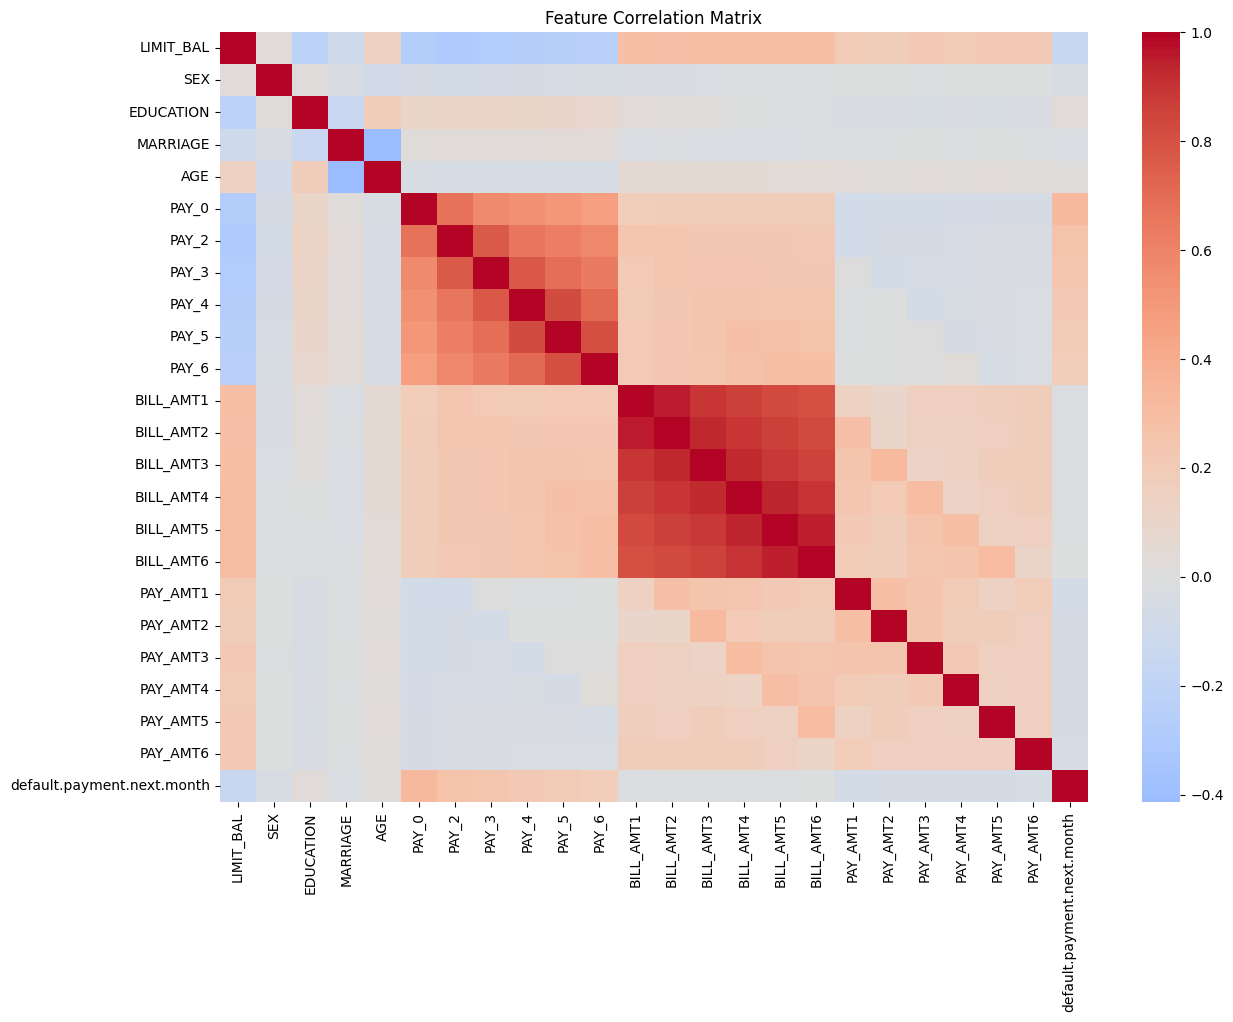

In [32]:
feature_cols = [c for c in df.columns if c not in ("ID", target)]
fig, ax = plt.subplots(figsize=(14, 10))
corr = df[feature_cols + [target]].corr()

sns.heatmap(corr, annot=False, cmap="coolwarm", center=0, ax=ax)
ax.set_title("Feature Correlation Matrix")
plt.show()

In [33]:
# Top correlations with target
corr_with_target = corr[target].drop(target).abs().sort_values(ascending=False)
print("Top features correlated with default:")
print(corr_with_target.head(10))

Top features correlated with default:
PAY_0        0.324794
PAY_2        0.263551
PAY_3        0.235253
PAY_4        0.216614
PAY_5        0.204149
PAY_6        0.186866
LIMIT_BAL    0.153520
PAY_AMT1     0.072929
PAY_AMT2     0.058579
PAY_AMT4     0.056827
Name: default.payment.next.month, dtype: float64


PAY_0 имеет наибольшую корреляцию с дефолтом (0.32). Признаки платежной истории (PAY_0 - PAY_6) доминируют, тогда как суммы счетов и платежей слабо коррелируют с таргетом. BILL_AMT признаки сильно коррелируют друг с другом - ожидаемо, так как месячные балансы переносятся.

## 5. Payment status analysis

PAY_0 - PAY_6 кодируют статус погашения: -2 = нет потребления, -1 = полная оплата, 0 = revolving credit, 1+ = месяцы задержки платежа.

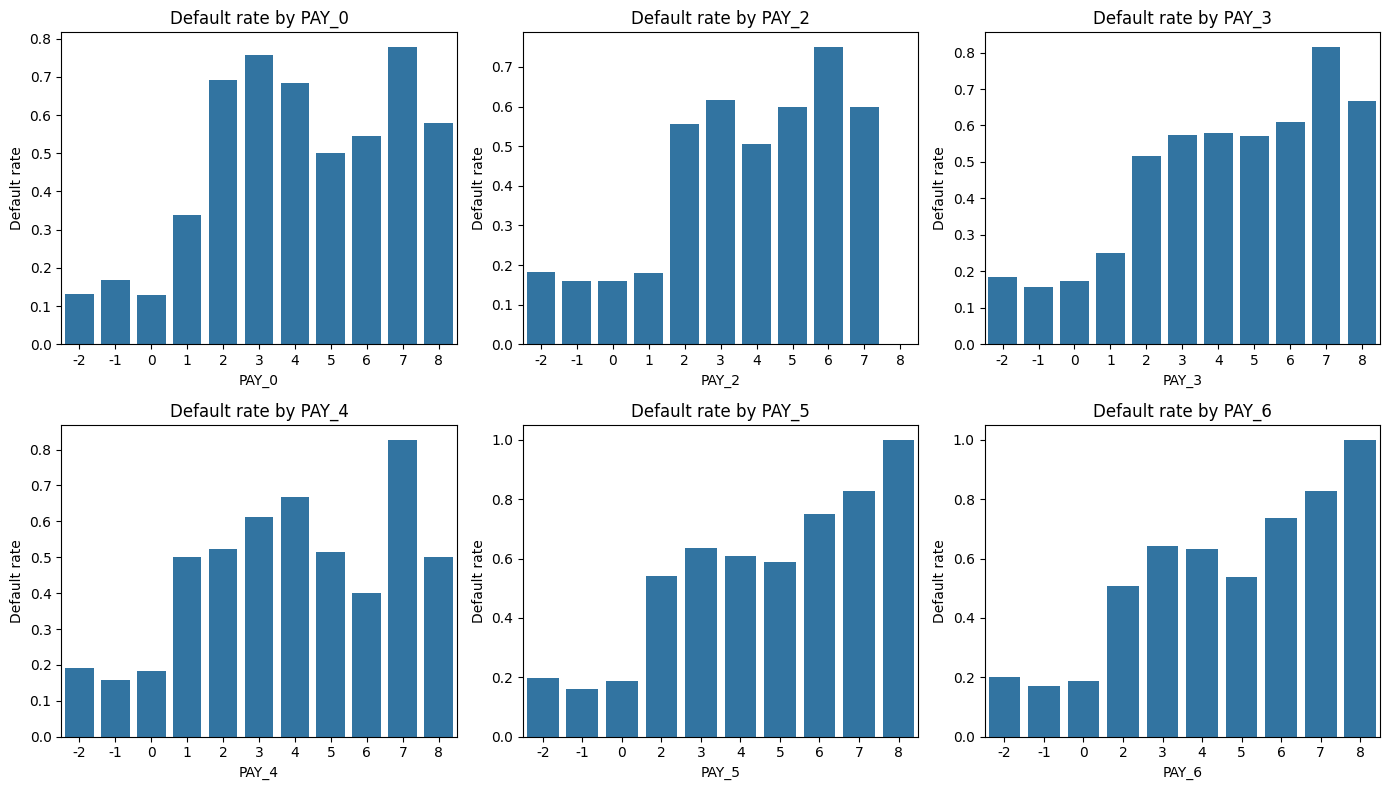

In [35]:
pay_cols = ["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for ax, col in zip(axes.flat, pay_cols):
    sns.barplot(data=df, x=col, y=target, ax=ax, errorbar=None)
    ax.set_title(f"Default rate by {col}")
    ax.set_ylabel("Default rate")

plt.tight_layout()
plt.show()

Четкий паттерн: default rate подскакивает с ~15% (вовремя) до ~70% (задержка 2+ месяца). История задержек платежей - сильнейший предиктор. Сложный feature engineering не нужен - сырые признаки уже достаточно информативны для градиентного бустинга.

## 6. Data preparation

In [36]:
feature_cols = [
    "LIMIT_BAL", "SEX", "EDUCATION", "MARRIAGE", "AGE",
    "PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6",
    "BILL_AMT1", "BILL_AMT2", "BILL_AMT3", "BILL_AMT4", "BILL_AMT5", "BILL_AMT6",
    "PAY_AMT1", "PAY_AMT2", "PAY_AMT3", "PAY_AMT4", "PAY_AMT5", "PAY_AMT6",
]

X = df[feature_cols]
y = df[target]

print(f"Features: {X.shape}")
print(f"Target: {y.shape}")
print(f"Missing values: {X.isnull().sum().sum()}")

Features: (30000, 23)
Target: (30000,)
Missing values: 0


In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train default rate: {y_train.mean():.3f}")
print(f"Test default rate:  {y_test.mean():.3f}")

Train: (24000, 23), Test: (6000, 23)
Train default rate: 0.221
Test default rate:  0.221


## 7. Model v1 - CatBoostClassifier

In [39]:
model_v1 = CatBoostClassifier(iterations=100, random_seed=42, verbose=0)
model_v1.fit(X_train, y_train)

y_pred_v1 = model_v1.predict(X_test)
y_proba_v1 = model_v1.predict_proba(X_test)[:, 1]

print("Model v1 - CatBoostClassifier")
print(classification_report(y_test, y_pred_v1, digits=4))
print(f"F1: {f1_score(y_test, y_pred_v1):.4f}")
print(f"ROC AUC: {roc_auc_score(y_test, y_proba_v1):.4f}")

Model v1 - CatBoostClassifier
              precision    recall  f1-score   support

           0     0.8376    0.9414    0.8864      4673
           1     0.6337    0.3572    0.4569      1327

    accuracy                         0.8122      6000
   macro avg     0.7356    0.6493    0.6717      6000
weighted avg     0.7925    0.8122    0.7914      6000

F1: 0.4569
ROC AUC: 0.7669


## 8. Model v2 - RandomForestClassifier

In [41]:
model_v2 = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model_v2.fit(X_train, y_train)

y_pred_v2 = model_v2.predict(X_test)
y_proba_v2 = model_v2.predict_proba(X_test)[:, 1]

print("Model v2 - RandomForestClassifier")
print(classification_report(y_test, y_pred_v2, digits=4))
print(f"F1: {f1_score(y_test, y_pred_v2):.4f}")
print(f"ROC AUC: {roc_auc_score(y_test, y_proba_v2):.4f}")

Model v2 - RandomForestClassifier
              precision    recall  f1-score   support

           0     0.8377    0.9409    0.8863      4673
           1     0.6325    0.3580    0.4572      1327

    accuracy                         0.8120      6000
   macro avg     0.7351    0.6494    0.6717      6000
weighted avg     0.7923    0.8120    0.7914      6000

F1: 0.4572
ROC AUC: 0.7506


## 9. Model comparison

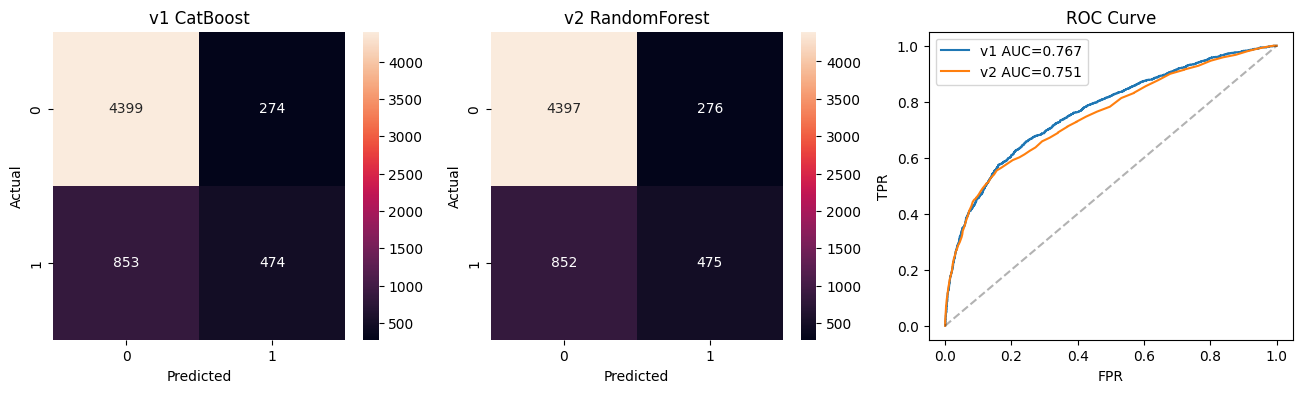

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, y_pred, title in [
    (axes[0], y_pred_v1, "v1 CatBoost"),
    (axes[1], y_pred_v2, "v2 RandomForest"),
]:
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

fpr_v1, tpr_v1, _ = roc_curve(y_test, y_proba_v1)
fpr_v2, tpr_v2, _ = roc_curve(y_test, y_proba_v2)

axes[2].plot(fpr_v1, tpr_v1, label=f"v1 AUC={roc_auc_score(y_test, y_proba_v1):.3f}")
axes[2].plot(fpr_v2, tpr_v2, label=f"v2 AUC={roc_auc_score(y_test, y_proba_v2):.3f}")
axes[2].plot([0, 1], [0, 1], "k--", alpha=0.3)
axes[2].set_title("ROC Curve")
axes[2].set_xlabel("FPR")
axes[2].set_ylabel("TPR")
axes[2].legend()

plt.show()

## 10. Feature importance

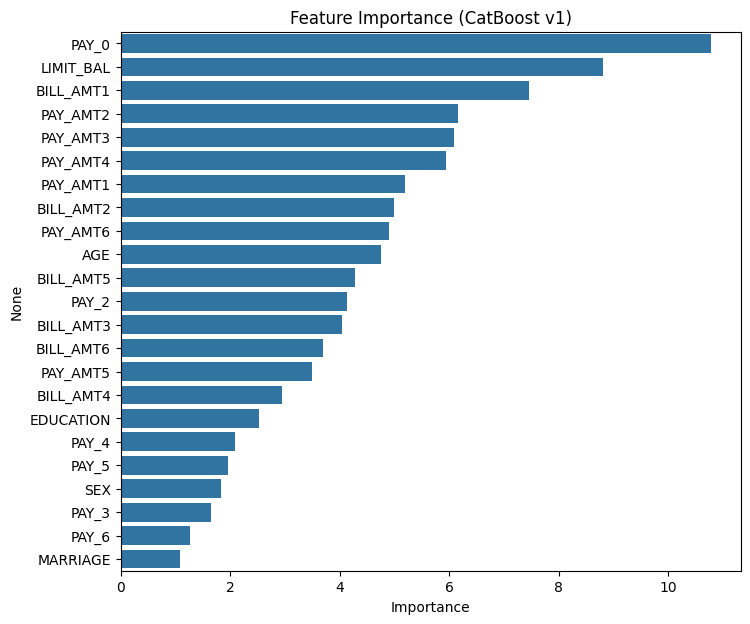

In [48]:
importance = pd.Series(model_v1.get_feature_importance(), index=feature_cols).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 7))
sns.barplot(x=importance.values, y=importance.index, ax=ax, orient="h")
ax.set_title("Feature Importance (CatBoost v1)")
ax.set_xlabel("Importance")

plt.show()

## 11. Save models

In [50]:
import os

models_dir = "../models"
os.makedirs(models_dir, exist_ok=True)

joblib.dump(model_v1, os.path.join(models_dir, "model_v1.pkl"))
joblib.dump(model_v2, os.path.join(models_dir, "model_v2.pkl"))

print("Models saved:")
for name in ["model_v1.pkl", "model_v2.pkl"]:

    size = os.path.getsize(os.path.join(models_dir, name))
    print(f"{name}: {size / 1024:.0f} KB")

Models saved:
model_v1.pkl: 118 KB
model_v2.pkl: 54246 KB


In [51]:
# Verify saved models load correctly
loaded_v1 = joblib.load(os.path.join(models_dir, "model_v1.pkl"))
loaded_v2 = joblib.load(os.path.join(models_dir, "model_v2.pkl"))

sample = X_test.iloc[:3]

print("Verification - predictions from loaded models:")
print(f"v1: {loaded_v1.predict(sample).tolist()}, proba: {loaded_v1.predict_proba(sample)[:, 1].round(3).tolist()}")
print(f"v2: {loaded_v2.predict(sample).tolist()}, proba: {loaded_v2.predict_proba(sample)[:, 1].round(3).tolist()}")

Verification - predictions from loaded models:
v1: [0, 0, 0], proba: [0.149, 0.117, 0.184]
v2: [0, 0, 0], proba: [0.19, 0.2, 0.16]
